In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.impute import SimpleImputer 

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from nltk.corpus import stopwords

import nltk

import warnings
warnings.filterwarnings('ignore')

In [48]:
# LOAD DATASET

df = pd.read_excel("moocs.xlsx")

df.columns = df.columns.str.strip()

print("First 5 Rows:")
print(df.head())



print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# DATASET INSPECTION

First 5 Rows:
                                                Text  Opinion(1/0)  \
0  Interesting! How often we say those things to ...             1   
1  What is \Algebra as a Math Game\" or are you j...             0   
2  I like the idea of my kids principal who says ...             1   
3  From their responses, it seems the students re...             1   
4  The boys loved math, because \there is freedom...             1   

   Question(1/0)  Answer(1/0)  Sentiment(1-7)  Confusion(1-7)  Urgency(1-7)  \
0              0            0             6.5             2.0           1.5   
1              1            0             4.0             5.0           3.5   
2              0            0             5.5             3.0           2.5   
3              0            0             6.0             3.0           2.5   
4              0            0             7.0             2.0           3.0   

  CourseType             forum_post_id                   course_display_name  \
0  Educati

In [49]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(29604, 18)


In [3]:
print('=== Basic Statistics ===')
display(df.describe())

=== Basic Statistics ===


,Opinion(1/0),Question(1/0),Answer(1/0),Sentiment(1-7),Confusion(1-7),Urgency(1-7),created_at,anonymous,anonymous_to_peers,up_count,reads
count,29604.000000,29604.000000,29604.000000,29604.000000,29604.000000,29604.000000,29585,29585.000000,29585.0,29585.000000,29585.000000
mean,0.556310,0.201290,0.204533,4.178658,3.910384,2.735171,2013-11-14 15:24:30.074396,0.017306,0.0,0.400980,410.736488
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2013-06-09 23:42:56,0.000000,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,4.000000,3.500000,1.500000,2013-08-06 21:12:30,0.000000,0.0,0.000000,16.000000
50%,1.000000,0.000000,0.000000,4.000000,4.000000,2.500000,2013-10-08 03:34:22,0.000000,0.0,0.000000,65.000000
75%,1.000000,0.000000,0.000000,4.500000,4.000000,3.500000,2014-02-06 05:46:26,0.000000,0.0,0.000000,191.000000
max,1.000000,1.000000,1.000000,7.000000,7.000000,7.000000,2014-08-08 08:00:36,1.000000,0.0,191.000000,9452.000000
std,0.496827,0.400971,0.403367,0.688520,0.606069,1.396435,NaN,0.130411,0.0,2.016614,1245.334869


In [4]:
# Show missing values before handling them
print("Missing Values Before Imputation:\n")
print(df.isnull().sum())

Missing Values Before Imputation:

Text                       1
Opinion(1/0)               0
Question(1/0)              0
Answer(1/0)                0
Sentiment(1-7)             0
Confusion(1-7)             0
Urgency(1-7)               0
CourseType                 2
forum_post_id             14
course_display_name       13
forum_uid                 19
created_at                19
post_type                 19
anonymous                 19
anonymous_to_peers        19
up_count                  19
comment_thread_id      12306
reads                     19
dtype: int64


In [5]:
print("Shape ", df.shape)


Shape  (29604, 18)


In [6]:
drop_cols = [
    'forum_post_id',
    'forum_uid',
    'comment_thread_id',
    'created_at'
]
# We used feature selection to remove irrelevant or low-value columns from the dataset. This helps to reduce noise, improve model performance, and decrease computational complexity by focusing on the most important features for the analysis.
#Some columns are:

#IDs (e.g., forum_uid, forum_post_id)
#metadata (created_at, course_display_name)
#repeated or non-informative fields (comment_thread_id)

#These do not contain useful patterns for the model.

In [7]:
df_clean = df.drop(columns=drop_cols)

In [8]:
# HANDLE MISSING VALUES

numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include=['object']).columns

# We used median for numerical columns because
# it is more robust to outliers than mean.

num_imputer = SimpleImputer(strategy='median')

df[numerical_cols] = num_imputer.fit_transform(
    df[numerical_cols]
)

# We used most_frequent for categorical columns
# to preserve category distribution.

cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(
    df[categorical_cols]
)

In [9]:
# REMOVE DUPLICATES

print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Duplicates: 0
Shape after removing duplicates: (29604, 18)


In [51]:
# DATETIME PROCESSING
if 'created_at' in df.columns:

    df['created_at'] = pd.to_datetime(
        df['created_at'],
        errors='coerce'
    )

    df['Year'] = df['created_at'].dt.year

    df['Month'] = df['created_at'].dt.month
    print(df.shape)
    

(29604, 20)


In [52]:
#TEXT CLEANING

text_column = 'Text'


def clean_text(text):

    text = str(text).lower()

    # remove links
    text = re.sub(r'http\\S+', '', text)

    # remove emails
    text = re.sub(r'\\S+@\\S+', '', text)

    # remove phone numbers
    text = re.sub(r'\\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # remove extra spaces
    text = re.sub(r'\\s+', ' ', text)

    return text


df[text_column] = df[text_column].apply(clean_text)

print(df.shape)

(29604, 20)


In [12]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\malak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
# REMOVE STOPWORDS

stop_words = set(stopwords.words('english'))


df[text_column] = df[text_column].apply(

    lambda x: ' '.join(

        word for word in x.split()

        if word not in stop_words
    )
)


In [14]:
#  FEATURE ENGINEERING

# Convert reads into categories

df['reads_category'] = pd.cut(

    df['reads'],

    bins=[0, 500, 2000, 100000],

    labels=['Low', 'Medium', 'High']
)


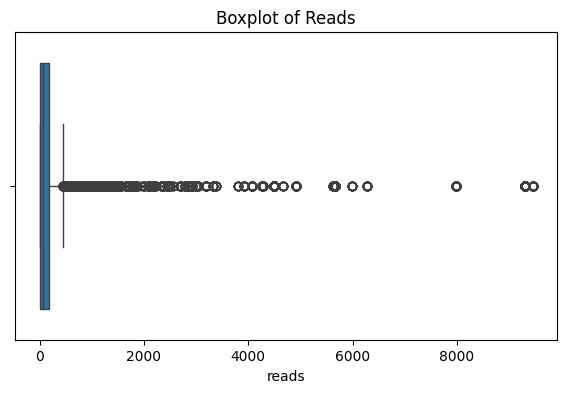

Number of Outliers: 3903


In [15]:
#  OUTLIER DETECTION

plt.figure(figsize=(7,4))

sns.boxplot(x=df['reads'])

plt.title("Boxplot of Reads")

plt.show()

Q1 = df['reads'].quantile(0.25)

Q3 = df['reads'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df['reads'] < lower) |
    (df['reads'] > upper)
]

print("Number of Outliers:", len(outliers))

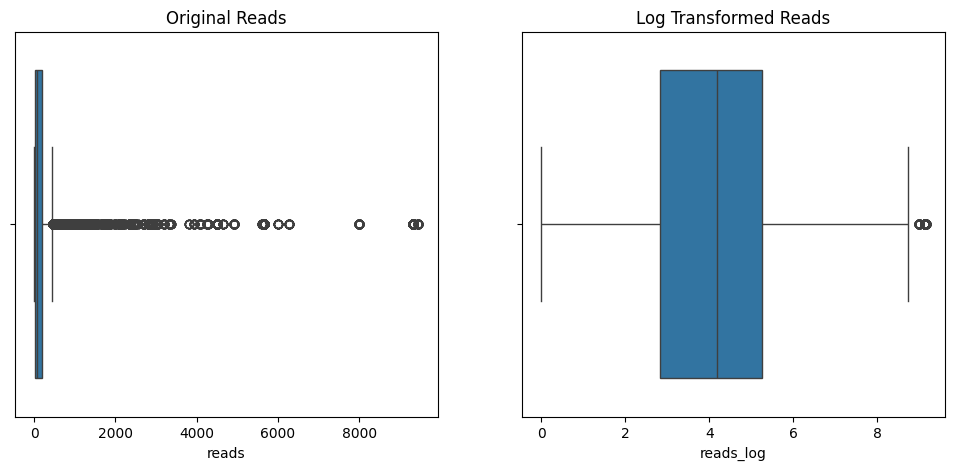

In [16]:
# LOG TRANSFORMATION

# log1p helps reduce skewness and handles zeros safely

df['reads_log'] = np.log1p(df['reads'])

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(x=df['reads'], ax=axes[0])

axes[0].set_title("Original Reads")

sns.boxplot(x=df['reads_log'], ax=axes[1])

axes[1].set_title("Log Transformed Reads")

plt.show()

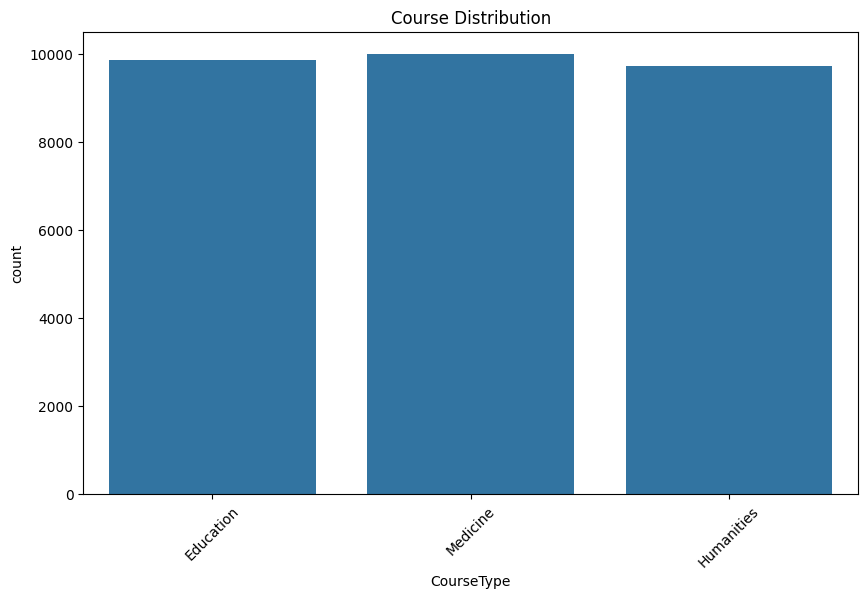

In [17]:
#  DESCRIPTIVE ANALYSIS

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='CourseType'
)

plt.xticks(rotation=45)

plt.title("Course Distribution")

plt.show()


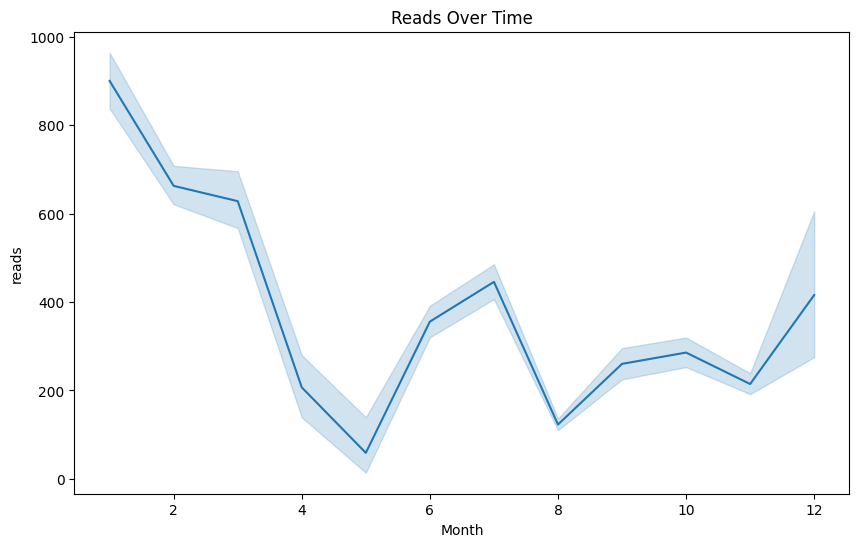

In [18]:
# Time analysis

if 'Month' in df.columns:

    plt.figure(figsize=(10,6))

    sns.lineplot(
        data=df,
        x='Month',
        y='reads'
    )

    plt.title("Reads Over Time")

    plt.show()

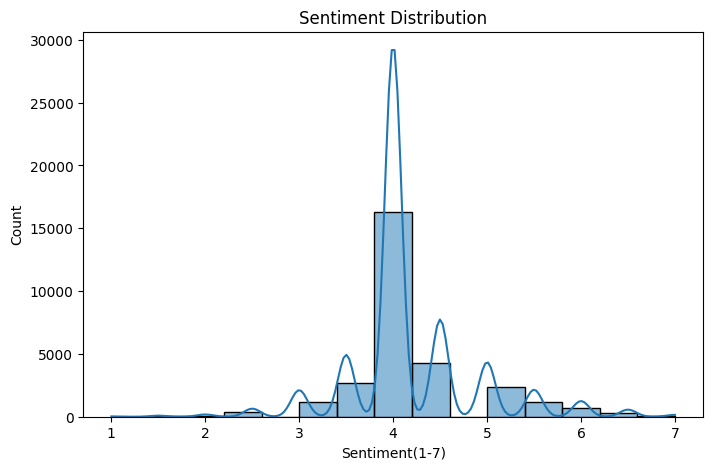

In [19]:
# Sentiment Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Sentiment(1-7)'],
    bins=15,
    kde=True
)

plt.title("Sentiment Distribution")

plt.show()

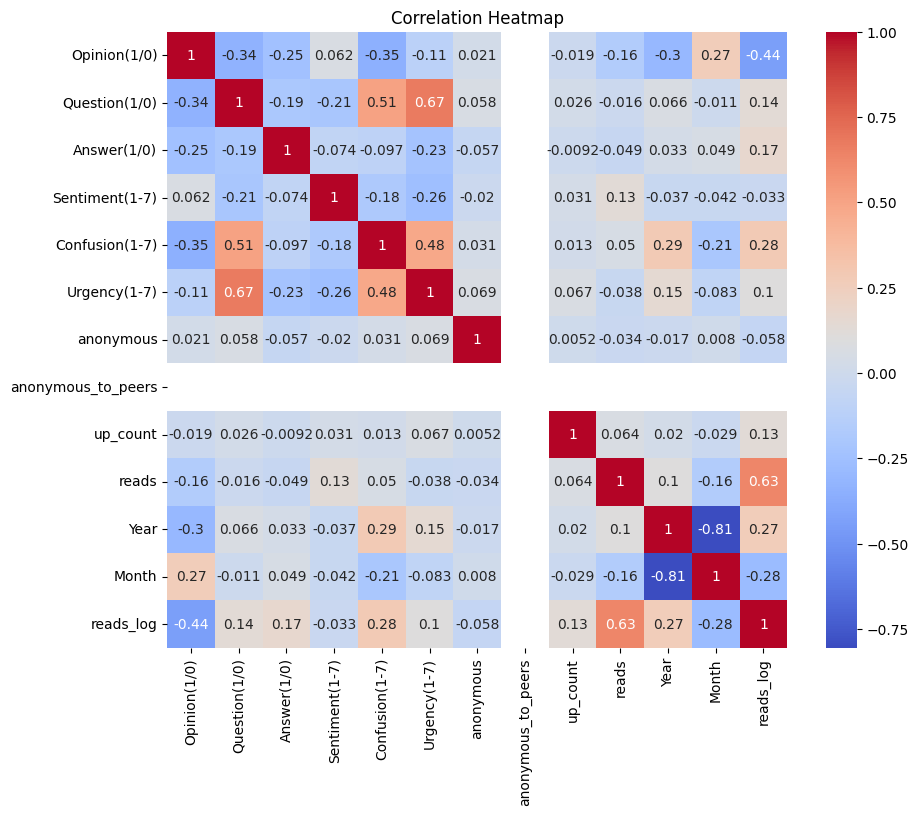

In [20]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(

    df.select_dtypes(include=np.number).corr(),

    annot=True,

    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


In [21]:
#  LABEL ENCODING

label_encoder = LabelEncoder()

for col in categorical_cols:

    df[col] = label_encoder.fit_transform(
        df[col].astype(str)
    )


In [22]:
#  TARGET VARIABLE

y = df['Opinion(1/0)']

In [23]:
#  TERM FREQUENCY

# Convert text column to string
df[text_column] = df[text_column].astype(str)

# Create Count Vectorizer
count_vectorizer = CountVectorizer(
    max_features=3000
)

# Apply Term Frequency
X_tf = count_vectorizer.fit_transform(
    df[text_column]
)

print("TF Shape:", X_tf.shape)

TF Shape: (29604, 3000)


In [24]:
#  TF-IDF

# TF-IDF reduces the effect of common words
# and highlights important words

tfidf_vectorizer = TfidfVectorizer(
    max_features=3000
)

X_tfidf = tfidf_vectorizer.fit_transform(
    df[text_column]
)

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (29604, 3000)


In [25]:
#  PCA

# PCA reduces dimensionality while preserving
# important information

pca = PCA(n_components=100)

X_pca = pca.fit_transform(
    X_tfidf.toarray()
)

print("PCA Shape:", X_pca.shape)

PCA Shape: (29604, 100)


In [26]:
# FEATURE SELECTION

selector = SelectKBest(
    chi2,
    k=100
)

X_selected = selector.fit_transform( 
    X_tfidf,
    y
)

print("Selected Features Shape:", X_selected.shape)

Selected Features Shape: (29604, 100)


In [27]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [28]:
# NORMALIZATION COMPARISON

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Compare scaling vs no scaling

svm_no_scale = SVC(kernel='linear')

svm_no_scale.fit(X_train, y_train)

y_pred_no_scale = svm_no_scale.predict(X_test)

print(
    "SVM Without Scaling:",
    accuracy_score(y_test, y_pred_no_scale)
)


SVM Without Scaling: 0.5705117378821145


In [29]:
#  CLASS IMBALANCE HANDLING

# Over Sampling

oversample = RandomOverSampler(random_state=42)

X_over, y_over = oversample.fit_resample(
    X_train,
    y_train
)


# Under Sampling

undersample = RandomUnderSampler(random_state=42)

X_under, y_under = undersample.fit_resample(
    X_train,
    y_train
)



In [30]:
# NAIVE BAYES

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:")

print(
    accuracy_score(y_test, y_pred_nb)
)

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

Naive Bayes Accuracy:
0.5759162303664922
              precision    recall  f1-score   support

         0.0       0.95      0.05      0.09      2627
         1.0       0.57      1.00      0.72      3294

    accuracy                           0.58      5921
   macro avg       0.76      0.52      0.41      5921
weighted avg       0.74      0.58      0.44      5921



In [31]:
# SVM LINEAR

svm_linear = SVC(
    kernel='linear'
)

svm_linear.fit(
    X_train_scaled,
    y_train
)

y_pred_svm_linear = svm_linear.predict(
    X_test_scaled
)

print("SVM Linear Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred_svm_linear
    )
)

print(
    classification_report(
        y_test,
        y_pred_svm_linear
    )
)

SVM Linear Accuracy:
0.5754095591960817
              precision    recall  f1-score   support

         0.0       0.89      0.05      0.09      2627
         1.0       0.57      1.00      0.72      3294

    accuracy                           0.58      5921
   macro avg       0.73      0.52      0.41      5921
weighted avg       0.71      0.58      0.44      5921



In [32]:
# SVM RBF

svm_rbf = SVC(
    kernel='rbf'
)

svm_rbf.fit(
    X_train_scaled,
    y_train
)

y_pred_svm_rbf = svm_rbf.predict(
    X_test_scaled
)

print("SVM RBF Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred_svm_rbf
    )
)

SVM RBF Accuracy:
0.5752406688059449


In [33]:
# RANDOM FOREST

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:")

print(
    accuracy_score(y_test, y_pred_rf)
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Accuracy:
0.5752406688059449
              precision    recall  f1-score   support

         0.0       0.88      0.05      0.09      2627
         1.0       0.57      0.99      0.72      3294

    accuracy                           0.58      5921
   macro avg       0.72      0.52      0.41      5921
weighted avg       0.71      0.58      0.44      5921



In [34]:
# ADABOOST

ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Accuracy:")

print(
    accuracy_score(y_test, y_pred_ada)
)

AdaBoost Accuracy:
0.5595338625232225


In [35]:
#  LOGISTIC REGRESSION

# Compare normal vs balanced class weights

log_normal = LogisticRegression(
    max_iter=1000
)

log_normal.fit(
    X_train_scaled,
    y_train
)

pred_normal = log_normal.predict(
    X_test_scaled
)

print(
    "Without Class Weight:",
    accuracy_score(y_test, pred_normal)
)

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(
    X_train_scaled,
    y_train
)

y_pred_log = log_model.predict(
    X_test_scaled
)

print("Logistic Regression Accuracy:")

print(
    accuracy_score(y_test, y_pred_log)
)

print(
    classification_report(
        y_test,
        y_pred_log
    )
)


Without Class Weight: 0.5752406688059449
Logistic Regression Accuracy:
0.5752406688059449
              precision    recall  f1-score   support

         0.0       0.87      0.05      0.09      2627
         1.0       0.57      0.99      0.72      3294

    accuracy                           0.58      5921
   macro avg       0.72      0.52      0.41      5921
weighted avg       0.70      0.58      0.44      5921



In [36]:
# CLASSIFICATION REPORT

print(

    classification_report(
        y_test,
        y_pred_rf
    )
)


              precision    recall  f1-score   support

         0.0       0.88      0.05      0.09      2627
         1.0       0.57      0.99      0.72      3294

    accuracy                           0.58      5921
   macro avg       0.72      0.52      0.41      5921
weighted avg       0.71      0.58      0.44      5921



In [37]:
#  MODEL COMPARISON

results = pd.DataFrame({

    'Model': [

        'Naive Bayes',

        'SVM Linear',

        'SVM RBF',

        'Random Forest',

        'AdaBoost',

        'Logistic Regression'
    ],

    'Accuracy': [

        accuracy_score(y_test, y_pred_nb),

        accuracy_score(y_test, y_pred_svm_linear),

        accuracy_score(y_test, y_pred_svm_rbf),

        accuracy_score(y_test, y_pred_rf),

        accuracy_score(y_test, y_pred_ada),

        accuracy_score(y_test, y_pred_log)
    ]
})

print(results)


                 Model  Accuracy
0          Naive Bayes  0.575916
1           SVM Linear  0.575410
2              SVM RBF  0.575241
3        Random Forest  0.575241
4             AdaBoost  0.559534
5  Logistic Regression  0.575241


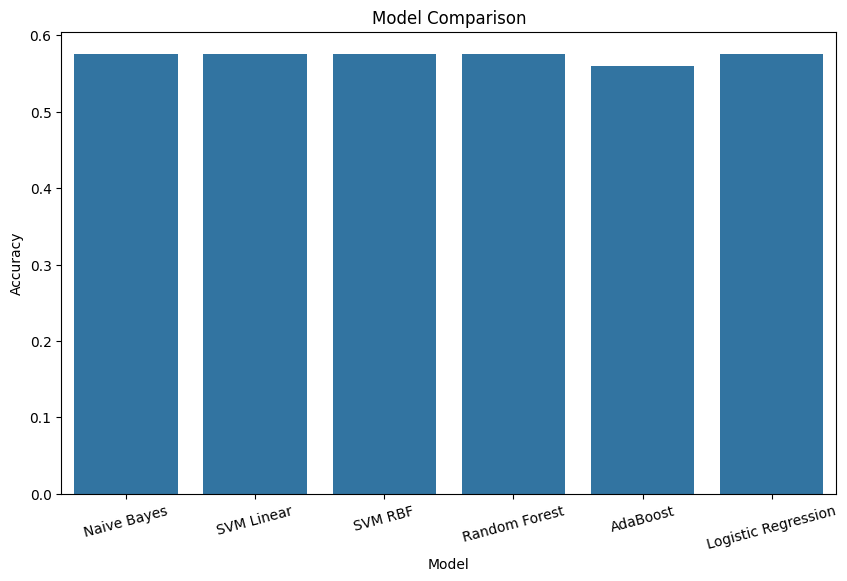

In [38]:
#  ACCURACY VISUALIZATION

plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.xticks(rotation=15)

plt.title("Model Comparison")

plt.show()

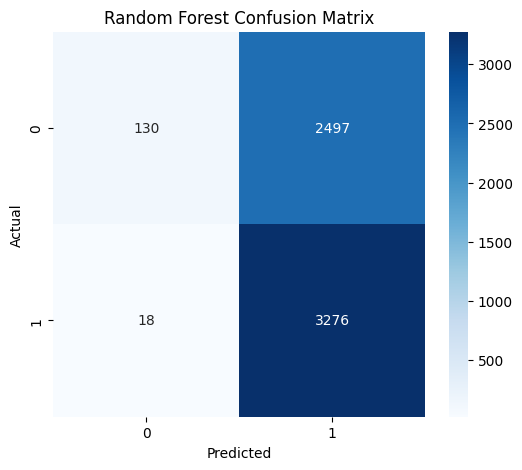

In [39]:
# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [ ]:
# GRID SEARCH - SVM

svm_params = {

    'C': [0.1, 1, 10],

    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(

    SVC(),

    svm_params,

    cv=3,

    scoring='accuracy'
)

grid_svm.fit(
    X_train_scaled,
    y_train
)

print("Best SVM Parameters:")

print(grid_svm.best_params_)

print("Best SVM Score:")

print(grid_svm.best_score_)

compare between TF-IDF and empedding features to see which one gives better performance.

Best SVM Parameters:
{'C': 1, 'kernel': 'rbf'}
Best SVM Score:
0.5943924778275202


In [41]:
# RANDOM FOREST TUNING

rf_params = {

    'n_estimators': [50, 100],

    'max_depth': [None, 10]
}

grid_rf = GridSearchCV(

    RandomForestClassifier(),

    rf_params,

    cv=3,

    scoring='accuracy'
)

grid_rf.fit(
    X_train,
    y_train
)

print("Best RF Parameters:")

print(grid_rf.best_params_)

print("Best RF Score:")

print(grid_rf.best_score_)



Best RF Parameters:
{'max_depth': None, 'n_estimators': 50}
Best RF Score:
0.5737448359862541


In [42]:
#  KMEANS CLUSTERING

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

df['Cluster'] = clusters

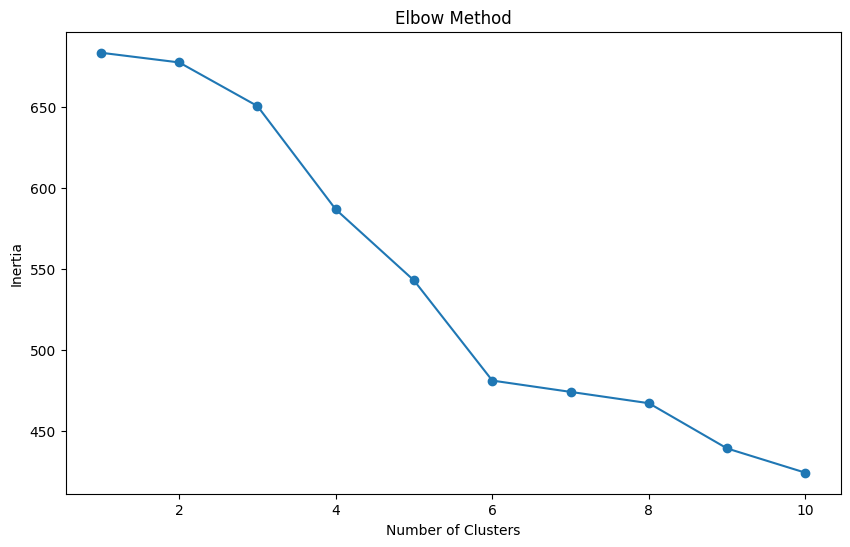

In [43]:
# ELBOW METHOD

inertia = []

for k in range(1, 11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X_pca)

    inertia.append(km.inertia_)

plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()


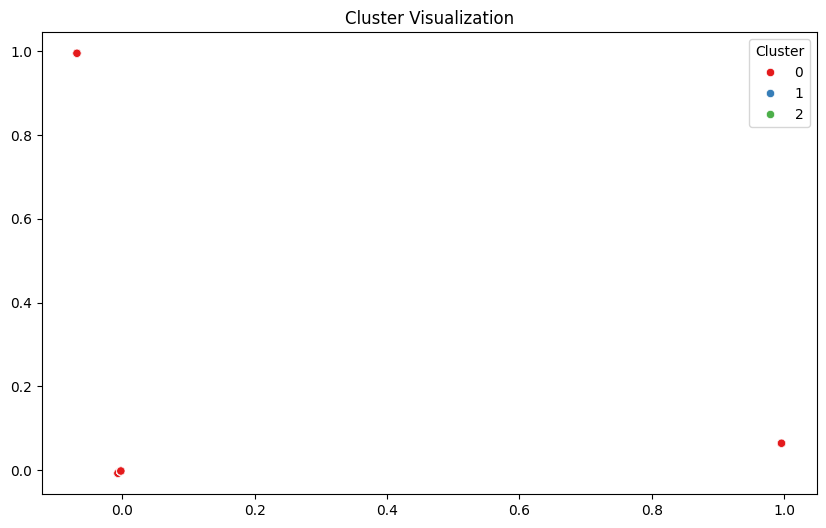

In [44]:
#  CLUSTER VISUALIZATION

plt.figure(figsize=(10,6))

sns.scatterplot(

    x=X_pca[:,0],

    y=X_pca[:,1],

    hue=df['Cluster'],

    palette='Set1'
)

plt.title("Cluster Visualization")

plt.show()

In [ ]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({

    'Feature': count_vectorizer.get_feature_names_out(),

    'Importance': rf_model.feature_importances_[
        :len(count_vectorizer.get_feature_names_out())
    ]
})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False
)

print(feature_importance.head(10))



     Feature  Importance
2858   22811    0.019198
2870   23224    0.012960
2943    6225    0.005601
2861   22988    0.005010
2819   18317    0.004581
2912   28188    0.004491
22     10175    0.004431
2944    6226    0.003855
2877   23497    0.003661
2950    6656    0.002671


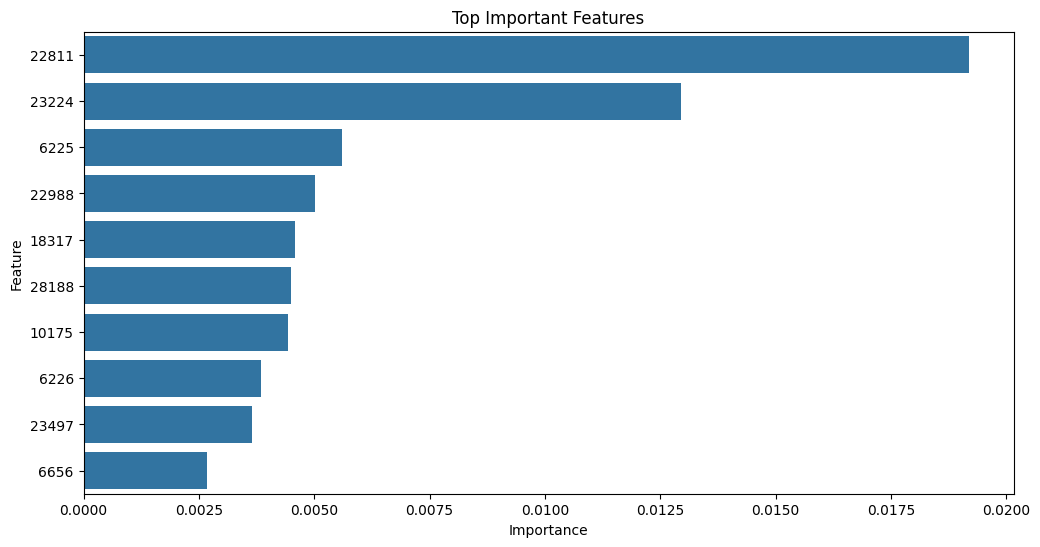

In [46]:
#FEATURE IMPORTANCE VISUALIZATION

plt.figure(figsize=(12,6))

sns.barplot(

    data=feature_importance.head(10),

    x='Importance',

    y='Feature'
)

plt.title("Top Important Features")

plt.show()

In [47]:
# FINAL CONCLUSION

# This project applied NLP preprocessing, 
#     classification, clustering, 
#     dimensionality reduction, 
#     feature selection, 
#      and hyperparameter tuning.


#     TF, TF-IDF, PCA, and balancing techniques 
#     were compared.


#     SVM kernels and Random Forest 
#     showed strong classification performance.


In [ ]:
# What outlier technique did you use?

# Answer:

# I used the IQR (Interquartile Range) method to detect outliers because it is robust to skewed data and does not assume normal distribution.
# I also used boxplots for visualization and log transformation using log1p to reduce skewness.

# Why did you use IQR?

# BEST ANSWER:

# IQR is resistant to extreme values and works well for skewed distributions, unlike methods that depend on mean and standard deviation.

# Example of Technique You DIDN’T Use
# Z-Score Method

# You can say:

# I did not use Z-score because it assumes normal distribution and is sensitive to extreme values.

# VERY GOOD academic answer.

# Another technique you didn’t use
# Winsorization

# You can say:

# I did not use Winsorization because I did not want to replace extreme values artificially and potentially lose meaningful information from highly active users.

# VERY IMPORTANT

# You DID NOT REMOVE OUTLIERS.

# You only: